In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

In [2]:
X_train = np.load("../data/processed/rul_dataset/X_train.npy")
X_test = np.load("../data/processed/rul_dataset/X_test.npy")

y_rul_train = np.load("../data/processed/rul_dataset/y_rul_train.npy")
y_rul_test = np.load("../data/processed/rul_dataset/y_rul_test.npy")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_rul_train:", y_rul_train.shape)
print("y_rul_test:", y_rul_test.shape)

X_train: (14241, 30, 15)
X_test: (3490, 30, 15)
y_rul_train: (14241,)
y_rul_test: (3490,)


In [3]:
print("Training RUL:")
print(pd.Series(y_rul_train).describe())

print("\nTesting RUL:")
print(pd.Series(y_rul_test).describe())

Training RUL:
count    14241.000000
mean        94.752897
std         62.776200
min          0.000000
25%         44.000000
50%         89.000000
75%        136.000000
max        332.000000
dtype: float64

Testing RUL:
count    3490.000000
mean       91.693123
std        58.254682
min         0.000000
25%        43.000000
50%        87.000000
75%       132.750000
max       239.000000
dtype: float64


In [4]:
X_train_rul = X_train[:, -1, :]
X_test_rul = X_test[:, -1, :]

print("X_train_rul:", X_train_rul.shape)
print("X_test_rul:", X_test_rul.shape)

X_train_rul: (14241, 15)
X_test_rul: (3490, 15)


In [5]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42
)


xgb_model.fit(
    X_train_rul,
    y_rul_train,
    eval_set=[(X_test_rul, y_rul_test)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [6]:
y_rul_pred = xgb_model.predict(X_test_rul)

In [7]:
mae_xgb = mean_absolute_error(y_rul_test, y_rul_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_rul_test, y_rul_pred))
r2_xgb = r2_score(y_rul_test, y_rul_pred)

print("RUL Prediction Results")
print("----------------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)


RUL Prediction Results
----------------------
MAE : 21.954673767089844
RMSE: 30.291059387360384
R²  : 0.7295470237731934


In [8]:
sample = X_test_rul[0].reshape(1, -1)

predicted_rul = xgb_model.predict(sample)[0]

print("Predicted RUL:", round(predicted_rul, 2), "cycles")

Predicted RUL: 160.56 cycles


WITH XGBREGRESSOR AS BASELINE USING LSTM 

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
np.random.seed(42)
tf.random.set_seed(42)

In [11]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_rul_train.shape)
print("y_test :", y_rul_test.shape)

X_train: (14241, 30, 15)
X_test : (3490, 30, 15)
y_train: (14241,)
y_test : (3490,)


In [12]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

c:\Users\pawan\Desktop\InfosysSpringBoard\Industrial-Maintenance-and-Process-Optimization-System\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
history = lstm_model.fit(
    X_train,
    y_rul_train,
    epochs=30,
    batch_size=64,
    shuffle=False,
    verbose=1
)

Epoch 1/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 7889.2681 - mae: 69.4748
Epoch 2/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 2449.9377 - mae: 34.6249
Epoch 3/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1738.6589 - mae: 29.2197
Epoch 4/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1628.0781 - mae: 28.3895
Epoch 5/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1546.8636 - mae: 27.4242
Epoch 6/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1530.1915 - mae: 27.4595
Epoch 7/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1490.1257 - mae: 26.7312
Epoch 8/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1458.6793 - mae: 26.5444
Epoch 9/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 1433.2758 - mae: 26.0438
Epoch 10/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1522.4702 - mae: 27.4114
Epoch 11/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1444.9877 - mae: 26.4034
Epoch 12/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/ste

In [14]:
y_rul_pred_lstm2 = lstm_model.predict(X_test, verbose=0 ).flatten()



In [15]:
mae_lstm = mean_absolute_error(y_rul_test, y_rul_pred_lstm2)
rmse_lstm = np.sqrt(mean_squared_error(y_rul_test, y_rul_pred_lstm2))
r2_lstm = r2_score(y_rul_test, y_rul_pred_lstm2)

print("Deep LSTM Results")
print("-----------------")
print("MAE :", mae_lstm)
print("RMSE:", rmse_lstm)
print("R²  :", r2_lstm)

Deep LSTM Results
-----------------
MAE : 20.06024742126465
RMSE: 28.48738006124653
R²  : 0.7607963681221008


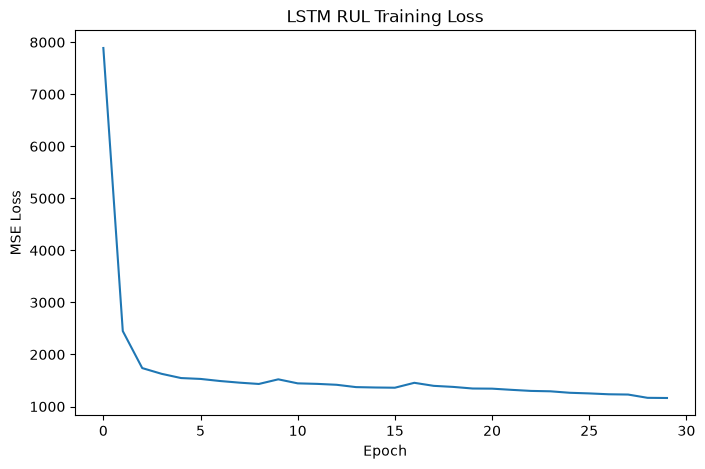

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"])

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM RUL Training Loss")

plt.show()

In [17]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "LSTM"],
    "MAE": [mae_xgb, mae_lstm],
    "RMSE": [rmse_xgb, rmse_lstm],
    "R2": [r2_xgb, r2_lstm]
})

comparison

,Model,MAE,RMSE,R2
0,XGBoost,21.954674,30.291059,0.729547
1,LSTM,20.060247,28.487380,0.760796


In [18]:
lstm_model.save("../models/rul_prediction_lstm.keras")